In [39]:
import pandas as pd
# Librerías para datos y gráficos
import numpy as np          # Para trabajar con arreglos numéricos
import pandas as pd         # Para manejar tablas de datos (DataFrames)
import matplotlib.pyplot as plt  # Para hacer gráficos
import seaborn as sns

from sklearn.feature_selection import chi2

# Herramientas de machine learning (scikit-learn)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc                       # Medir calidad de los modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Modelos de árboles

# Para análisis de supervivencia
from lifelines import KaplanMeierFitter                                       # Para crear curvas de supervivencia
from lifelines.statistics import logrank_test                                 # Prueba para comparar curvas
from sksurv.ensemble import RandomSurvivalForest                              # Modelo de bosque para supervivencia
from sksurv.util import Surv                                                   # Formato de datos para supervivencia
from sksurv.metrics import concordance_index_censored                        # Medida para evaluar modelos de supervivencia

# Para balancear datos y generar muestras nuevas
from imblearn.over_sampling import SMOTE                                   # Para balancear datos desbalanceados

# Para usar XGBoost, un modelo potente basado en árboles
import xgboost as xgb     
from xgboost import XGBClassifier     

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [40]:
top25_genes = [
    "CD74",
    "HLA-DPB1",
    "HLA-DRB1",
    "HLA-DMA",
    "HLA-DMB",
    "HLA-DRA",
    "HLA-DPA1",
    "HLA-DOA",
    "HLA-E",
    "HLA-DQA1",
    "PTPRC",
    "LYN",
    "IL10",
    "CD3E",
    "FCGR3A",
    "LCK",
    "CASP1",
    "CD2",
    "B2M",
    "LCP2",
    "SERPING1",
    "CD4",
    "FCER1G",
    "C1QB",
    "C1QC"
]

In [41]:
top25_genes = [
    'CD74', 'HLA-DPB1', 'HLA-DRB1', 'HLA-DMA', 'HLA-DMB', 'HLA-DRA', 'HLA-DPA1', 'HLA-DOA', 'HLA-E', 'HLA-DQA1', 'PTPRC', 'LYN', 'IL10', 'CD3E', 'FCGR3A', 'LCK', 'CASP1', 'CD2', 'B2M', 'LCP2', 'SERPING1', 'CD4', 'FCER1G', 'C1QB', 'C1QC', 'RUNX1', 'HLA-C', 'SYK', 'TIMP1', 'CD44', 'MMP14', 'IL7R', 'COL1A2', 'ISG15', 'IFI44L', 'RSAD2', 'MAOB', 'CASP4', 'CCR5', 'CASP8', 'CTSS', 'CCL5', 'DAPP1', 'HLA-B', 'ITGB2', 'ITGA5', 'PLCG2', 'TYROBP', 'ALOX5', 'LSP1', 'GZMA', 'HLA-DQB1', 'CCR2', 'CYBA', 'NCF1', 'CLEC7A', 'PTGS1', 'RIPK3', 'IL2RB', 'PYGL', 'CD53', 'RUNX3', 'GZMK', 'LAPTM5', 'SPI1', 'ICAM1', 'CD3D', 'CD86', 'HAVCR2', 'ALPK1', 'PTPN22', 'TIFA', 'CXCR3', 'PTPN6', 'CCR1', 'C1S', 'C2', 'HCK', 'VAV1', 'ITGB3', 'PIK3R5', 'HLA-DQA2', 'RNASE2', 'BTK', 'ITGB7', 'LILRB2', 'ANG', 'HCST', 'FCGR2B', 'PIK3R6', 'ITK', 'TLR7', 'PRF1', 'GZMH', 'TLR3', 'IFIH1', 'HERC5', 'COL1A1', 'CD80', 'CD163', 'SERPINH1', 'JAK3', 'CCL2', 'LGALS9C', 'PDCD1', 'LUM', 'TNFRSF11B', 'TNFSF10', 'XAF1', 'COL6A2', 'IFI44', 'ZBP1', 'PHEX', 'ENPP1', 'IRF7', 'SERPINE1', 'GZMB', 'GNLY', 'CXCR2', 'F3', 'CXCR4', 'VCAM1', 'IL6', 'EGR1', 'MMP9', 'FCAR', 'PIGR', 'ALDH3A1', 'AOX1', 'EGR2', 'IBSP', 'CEP55', 'KIF2C', 'HOXD11', 'HOXD10', 'PLBD1', 'SP100', 'CIITA', 'ADPRH', 'KYNU', 'SERPINA1', 'SQRDL', 'MSR1', 'S100A4', 'RAC2', 'FAM129A', 'S100A11', 'GPR65', 'CLIC1', 'PTGER4', 'IL2RG', 'GBP5', 'TRIM38', 'FGL2', 'CTSC', 'APOBEC3G', 'FCGR2A', 'IFI30', 'DENND2D', 'ARHGAP15', 'LTBR', 'TNFAIP8', 'CECR1', 'PLSCR1', 'MSN', 'FCGR2C', 'ELF4', 'ITGAL', 'CD7', 'MYOF', 'ARHGAP25', 'SP140L'
]

In [42]:
path_rppa = '../data/Human__TCGA_LGG__MDA__RPPA__MDA_RPPA__01_28_2016__BI__Gene__Firehose_RPPA.cct.txt'
path_mutation = '../data/Human__TCGA_LGG__WUSM__Mutation__GAIIx__01_28_2016__BI__Gene__Firehose_MutSig2CV.cbt.txt'

path_scna_gen = '../data/Human__TCGA_LGG__BI__SCNA__SNP_6.0__01_28_2016__BI__Gene__Firehose_GISTIC2.cct'

rppa = pd.read_csv(path_rppa, sep='\t', index_col=0)
muta = pd.read_csv(path_mutation, sep='\t', index_col=0)
scna_gen = pd.read_csv(path_scna_gen, sep='\t', index_col=0)

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

Dimensión datos rppa: (148, 429)
Dimensión datos mutaciones: (889, 513)
Dimensión datos scna: (24776, 513)


In [43]:
rppa = rppa.loc[rppa.index.isin(top25_genes)]
scna_gen = scna_gen.loc[scna_gen.index.isin(top25_genes)]
muta = muta.loc[muta.index.isin(top25_genes)]

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

print(scna_gen.index.tolist())

Dimensión datos rppa: (3, 429)
Dimensión datos mutaciones: (13, 513)
Dimensión datos scna: (158, 513)
['ISG15', 'C1QC', 'C1QB', 'RUNX3', 'LAPTM5', 'LCK', 'KIF2C', 'IFI44L', 'IFI44', 'GBP5', 'F3', 'VCAM1', 'CD53', 'DENND2D', 'PTPN22', 'CD2', 'CTSS', 'S100A11', 'S100A4', 'FCER1G', 'FCGR2A', 'FCGR2B', 'FCGR2C', 'FCGR3A', 'FAM129A', 'PTPRC', 'IL10', 'PIGR', 'RSAD2', 'ARHGAP25', 'GNLY', 'CXCR4', 'KYNU', 'ARHGAP15', 'IFIH1', 'HOXD10', 'HOXD11', 'AOX1', 'CASP8', 'CXCR2', 'SP140L', 'SP100', 'PDCD1', 'CCR1', 'CCR2', 'CCR5', 'CD80', 'ADPRH', 'CD86', 'PLSCR1', 'TNFSF10', 'IBSP', 'HERC5', 'DAPP1', 'TIFA', 'ALPK1', 'TLR3', 'IL7R', 'PTGER4', 'GZMK', 'GZMA', 'TNFAIP8', 'EGR1', 'CD74', 'HAVCR2', 'ITK', 'LCP2', 'TRIM38', 'C2', 'CLIC1', 'ENPP1', 'IL6', 'NCF1', 'FGL2', 'COL1A2', 'SERPINE1', 'MSR1', 'LYN', 'TNFRSF11B', 'SYK', 'PTGS1', 'ALOX5', 'EGR2', 'PRF1', 'MYOF', 'CEP55', 'IRF7', 'CD44', 'SPI1', 'SERPING1', 'SERPINH1', 'CTSC', 'CASP4', 'CASP1', 'CD3E', 'CD3D', 'LTBR', 'CD4', 'PTPN6', 'C1S', 'CD163', '

In [44]:
scna_gen = scna_gen.T 
scna_gen.head()

attrib_name,ISG15,C1QC,C1QB,RUNX3,LAPTM5,LCK,KIF2C,IFI44L,IFI44,GBP5,F3,VCAM1,CD53,DENND2D,PTPN22,CD2,CTSS,S100A11,S100A4,FCER1G,FCGR2A,FCGR2B,FCGR2C,FCGR3A,FAM129A,PTPRC,IL10,PIGR,RSAD2,ARHGAP25,GNLY,CXCR4,KYNU,ARHGAP15,IFIH1,HOXD10,HOXD11,AOX1,CASP8,CXCR2,...,ITGAL,PLCG2,CYBA,XAF1,PIK3R6,PIK3R5,LGALS9C,ALDH3A1,CCL2,CCL5,ITGB3,COL1A1,CD7,VAV1,ICAM1,JAK3,IFI30,HCST,TYROBP,LILRB2,FCAR,HCK,MMP9,ZBP1,RUNX1,ITGB2,COL6A2,CECR1,IL2RB,RAC2,APOBEC3G,TLR7,PHEX,MAOB,TIMP1,MSN,IL2RG,CXCR3,BTK,ELF4
TCGA.CS.4938,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.004,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,0.001,0.001,0.001,-0.001,-0.001,-0.001,-0.001,-0.001,0.010,0.010,0.006,0.006,-0.019,0.008,0.008,0.008,0.008,0.008,0.008,0.008,0.008,-0.007,0.765,0.765,0.005,0.005,0.005,0.011,0.011,0.011,0.011,-0.206,-0.206,-0.206,-0.206,0.123,0.123,0.123,0.123,0.123
TCGA.CS.4941,0.459,0.459,0.459,0.459,0.459,0.459,0.459,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.447,0.446,0.444,0.444,0.444,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,...,0.026,0.026,0.026,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.021,0.021,0.021,0.021,0.021,0.021,0.021,0.021,0.021,0.021,0.021,0.022,0.022,0.022,0.013,0.029,0.029,0.029,0.012,0.012,0.000,0.000,0.000,0.000,0.000,0.000,0.000
TCGA.CS.4942,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,-0.006,-0.006,-0.006,-0.006,-0.006,-0.006,-0.006,-0.006,-0.006,-0.006,-0.006,0.003,...,0.014,0.014,0.067,0.033,0.033,0.033,0.033,0.033,0.033,0.033,0.033,0.033,0.033,0.020,0.020,0.020,0.020,0.020,0.020,-0.715,-0.715,0.019,0.019,0.019,-0.006,-0.006,-0.006,0.025,0.025,0.025,0.025,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.016
TCGA.CS.4943,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.033,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,-0.032,...,0.003,0.008,0.008,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.005,-0.041,-0.041,-0.041,-0.041,-0.276,-0.276,-0.276,-0.276,-0.022,-0.022,-0.043,-0.106,-0.106,-0.106,-0.870,-0.870,-0.870,-0.870,-0.084,-0.084,-0.084,-0.084,-0.084,-0.084,-0.084,-0.084,-0.084
TCGA.CS.4944,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.009,-0.677,-0.677,-0.677,-0.677,-0.677,-0.691,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.001,0.001,0.001,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.016,0.016,...,-0.013,-0.013,-0.013,-0.016,-0.016,-0.016,-0.016,-0.016,-0.016,-0.016,-0.016,-0.016,-0.029,-0.015,-0.015,-0.025,-0.025,0.609,0.609,-0.674,-0.674,-0.027,-0.027,-0.027,-0.002,-0.002,-0.002,-0.027,-0.027,-0.027,-0.027,-0.048,-0.048,-0.048,-0.048,-0.048,-0.048,-0.048,-0.048,-0.048


In [45]:
data_cox = pd.read_csv('../data/data_cox_with_survival3yr_ht.csv', index_col=0)
data_cox.head()


,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,PTPRC,LYN,IL10,CD3E,FCGR3A,LCK,CASP1,CD2,B2M,LCP2,SERPING1,CD4,FCER1G,C1QB,C1QC,RUNX1,HLA-C,SYK,TIMP1,CD44,MMP14,IL7R,COL1A2,ISG15,IFI44L,RSAD2,MAOB,CASP4,CCR5,CASP8,...,LPAR6,TLR1,BATF,GIMAP2,PLAUR,CD48,HCP5,PLEK,FAM26F,LILRB1,C1RL,FERMT3,SIGLEC9,VAMP8,LHFPL2,SASH3,VNN2,BST2,SLC7A7,CLEC2B,IL13RA1,EMR2,SPN,CD300C,ARHGAP30,CISH,PTPLAD2,ANXA2,OAS2,SERPINA3,FES,CST7,LCP1,GPSM3,overall_survival,status,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,7.9303,8.9073,4.0093,2.5933,8.1529,1.6312,7.3958,1.6312,14.0208,7.6154,8.2515,10.1129,9.4675,11.3329,11.2728,7.1366,11.9802,9.4451,6.2577,12.9149,9.6435,1.4213,7.8194,7.5361,10.5103,5.5592,11.0000,6.2013,5.4527,5.9405,...,7.8005,6.8627,2.7811,6.3497,6.2176,2.6902,5.2920,8.9520,2.9473,7.3068,5.7735,8.2435,5.5847,8.3494,9.6083,8.3752,2.2558,8.7905,7.9203,5.9503,10.1052,3.2943,6.5885,5.8171,8.7905,4.3132,6.4291,10.3151,6.9967,10.3155,6.7434,1.4213,9.3821,8.5820,3574.0,False,1,1.0,0.0,0.0
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,9.5845,10.5100,4.0766,6.7406,11.8603,5.6538,8.4219,6.5359,15.7253,9.0451,11.8442,10.8098,9.7941,12.5445,12.4334,8.2576,14.5724,9.7363,11.0219,12.5383,11.1298,5.2318,10.4702,12.6932,13.3667,11.4291,13.1853,7.7338,7.4590,7.9546,...,9.0185,7.9201,5.4638,8.2913,7.6983,7.6119,9.4691,9.5993,7.1476,8.8036,8.9962,9.2930,7.0420,9.1644,10.8933,9.4705,5.0928,11.7477,8.7980,7.1925,10.6680,7.1335,7.4562,5.2580,9.2181,6.8220,7.9804,10.9965,12.2650,14.0145,8.2961,4.7850,10.4500,9.5249,234.0,True,0,1.0,0.0,0.0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,10.3002,10.4678,3.1064,4.1382,11.6896,3.4180,8.5825,4.3971,15.6693,9.2850,9.8687,11.6573,10.0406,13.3568,13.2014,8.8064,14.8054,10.1382,7.2401,11.4503,10.3773,4.1382,7.3297,12.2260,13.7671,10.3385,12.5283,7.0572,7.3141,6.5976,...,8.2969,8.4010,4.9429,8.5362,6.8821,7.5772,8.1622,9.6728,6.9361,8.8131,6.9278,9.3315,7.6951,9.4158,10.8325,9.3080,5.3624,11.0795,9.3338,5.4789,11.2354,7.5640,7.8802,6.3074,9.5656,5.7899,7.6260,7.7679,10.5123,9.3795,7.1965,3.3214,10.6753,9.9380,1335.0,True,1,1.0,0.0,0.0
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,8.2115,8.7019,2.4764,2.5585,10.3805,2.1975,7.1080,2.3893,13.6961,7.9089,7.9684,10.2035,8.4250,11.8849,11.9314,7.6074,11.7915,9.0803,7.1148,11.2096,10.0724,2.5585,9.2452,8.2067,9.8716,5.8433,7.5179,6.7010,5.2421,5.7414,...,8.4932,7.3348,3.7076,6.5833,6.5384,5.8837,6.2354,8.7660,5.5738,7.2100,5.5438,8.2194,5.9074,7.8612,9.5100,8.4373,2.8471,8.7767,8.4801,5.3029,9.6785,6.1585,5.9152,4.8273,8.2767,3.9399,6.7323,8.4223,7.6432,8.2147,6.9534,2.1975,9.4071,8.5049,1106.0,True,1,1.0,0.0,0.0
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,7.2412,8.1417,4.1817,5.0345,9.6133,3.6554,7.0236,3.9186,14.4556,6.9549,10.4694,9.5651,8.9940,11.4629,11.5642,6.8326,12.8809,8.6235,8.4112,14.3063,10.0623,2.5954,8.1748,8.6972,9.2545,6.7403,10.0432,6.0784,5.6705,5.5821,...,7.8890,5.5514,3.4036,7.5123,6.6197,5.8452,6.4047,8.1417,5.3697,5.9430,7.1157,7.9550,5.4552,8.7472,9.5123,7.7163,4.2973,9.6796,8.3501,6.4132,10.3180,3.6554,5.5972,5.0565,8.4155,3.7120,6.4386,10.9969,7.0348,15.4013,6.5437,4.0117,9.5651,8.7404,1828.0,False,1,1.0,0.0,0.0


In [46]:
# Renombrar columnas de SCNA para indicar origen "_scna"
scna_renamed = scna_gen.add_suffix('_scna')

# Renombrar columnas de expresión para indicar origen "_expression"
cox_renamed = data_cox.add_suffix('_expression')

# Mantener la columna survival_3yr sin sufijo
survival_col = data_cox['survival_3yr']

# Encontrar genes comunes
genes_cox = set([col.replace('_expression', '') for col in cox_renamed.columns])
genes_scna = set([col.replace('_scna', '') for col in scna_renamed.columns])
common_genes = genes_cox.intersection(genes_scna)

# Filtrar matrices por genes comunes
cols_cox_common = [gene + '_expression' for gene in common_genes]
cols_scna_common = [gene + '_scna' for gene in common_genes]

cox_filtered = cox_renamed[cols_cox_common]
scna_filtered = scna_renamed[cols_scna_common]

# Unir por índice de muestra
merged_data = pd.merge(cox_filtered, scna_filtered, left_index=True, right_index=True, how='inner')

# Añadir la columna survival_3yr
merged_data = merged_data.join(survival_col, how='inner')

# Ordenar columnas: expresión y SCNA lado a lado por gen
ordered_cols = []
for gene in sorted(common_genes):
    ordered_cols.append(gene + '_expression')
    ordered_cols.append(gene + '_scna')
ordered_cols.append('survival_3yr')

merged_data = merged_data[ordered_cols]

# Vista final
print(merged_data.head())



              ADPRH_expression  ADPRH_scna  ...  ZBP1_scna  survival_3yr
TCGA.CS.4938            6.4638       0.001  ...      0.765             1
TCGA.CS.4941            8.7398       0.018  ...      0.021             0
TCGA.CS.4942            7.7237      -0.009  ...      0.019             1
TCGA.CS.4943            6.8714      -0.008  ...     -0.043             1
TCGA.CS.4944            6.1822       0.015  ...     -0.027             1

[5 rows x 317 columns]


In [47]:
data_cox.head()

,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,PTPRC,LYN,IL10,CD3E,FCGR3A,LCK,CASP1,CD2,B2M,LCP2,SERPING1,CD4,FCER1G,C1QB,C1QC,RUNX1,HLA-C,SYK,TIMP1,CD44,MMP14,IL7R,COL1A2,ISG15,IFI44L,RSAD2,MAOB,CASP4,CCR5,CASP8,...,LPAR6,TLR1,BATF,GIMAP2,PLAUR,CD48,HCP5,PLEK,FAM26F,LILRB1,C1RL,FERMT3,SIGLEC9,VAMP8,LHFPL2,SASH3,VNN2,BST2,SLC7A7,CLEC2B,IL13RA1,EMR2,SPN,CD300C,ARHGAP30,CISH,PTPLAD2,ANXA2,OAS2,SERPINA3,FES,CST7,LCP1,GPSM3,overall_survival,status,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,7.9303,8.9073,4.0093,2.5933,8.1529,1.6312,7.3958,1.6312,14.0208,7.6154,8.2515,10.1129,9.4675,11.3329,11.2728,7.1366,11.9802,9.4451,6.2577,12.9149,9.6435,1.4213,7.8194,7.5361,10.5103,5.5592,11.0000,6.2013,5.4527,5.9405,...,7.8005,6.8627,2.7811,6.3497,6.2176,2.6902,5.2920,8.9520,2.9473,7.3068,5.7735,8.2435,5.5847,8.3494,9.6083,8.3752,2.2558,8.7905,7.9203,5.9503,10.1052,3.2943,6.5885,5.8171,8.7905,4.3132,6.4291,10.3151,6.9967,10.3155,6.7434,1.4213,9.3821,8.5820,3574.0,False,1,1.0,0.0,0.0
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,9.5845,10.5100,4.0766,6.7406,11.8603,5.6538,8.4219,6.5359,15.7253,9.0451,11.8442,10.8098,9.7941,12.5445,12.4334,8.2576,14.5724,9.7363,11.0219,12.5383,11.1298,5.2318,10.4702,12.6932,13.3667,11.4291,13.1853,7.7338,7.4590,7.9546,...,9.0185,7.9201,5.4638,8.2913,7.6983,7.6119,9.4691,9.5993,7.1476,8.8036,8.9962,9.2930,7.0420,9.1644,10.8933,9.4705,5.0928,11.7477,8.7980,7.1925,10.6680,7.1335,7.4562,5.2580,9.2181,6.8220,7.9804,10.9965,12.2650,14.0145,8.2961,4.7850,10.4500,9.5249,234.0,True,0,1.0,0.0,0.0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,10.3002,10.4678,3.1064,4.1382,11.6896,3.4180,8.5825,4.3971,15.6693,9.2850,9.8687,11.6573,10.0406,13.3568,13.2014,8.8064,14.8054,10.1382,7.2401,11.4503,10.3773,4.1382,7.3297,12.2260,13.7671,10.3385,12.5283,7.0572,7.3141,6.5976,...,8.2969,8.4010,4.9429,8.5362,6.8821,7.5772,8.1622,9.6728,6.9361,8.8131,6.9278,9.3315,7.6951,9.4158,10.8325,9.3080,5.3624,11.0795,9.3338,5.4789,11.2354,7.5640,7.8802,6.3074,9.5656,5.7899,7.6260,7.7679,10.5123,9.3795,7.1965,3.3214,10.6753,9.9380,1335.0,True,1,1.0,0.0,0.0
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,8.2115,8.7019,2.4764,2.5585,10.3805,2.1975,7.1080,2.3893,13.6961,7.9089,7.9684,10.2035,8.4250,11.8849,11.9314,7.6074,11.7915,9.0803,7.1148,11.2096,10.0724,2.5585,9.2452,8.2067,9.8716,5.8433,7.5179,6.7010,5.2421,5.7414,...,8.4932,7.3348,3.7076,6.5833,6.5384,5.8837,6.2354,8.7660,5.5738,7.2100,5.5438,8.2194,5.9074,7.8612,9.5100,8.4373,2.8471,8.7767,8.4801,5.3029,9.6785,6.1585,5.9152,4.8273,8.2767,3.9399,6.7323,8.4223,7.6432,8.2147,6.9534,2.1975,9.4071,8.5049,1106.0,True,1,1.0,0.0,0.0
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,7.2412,8.1417,4.1817,5.0345,9.6133,3.6554,7.0236,3.9186,14.4556,6.9549,10.4694,9.5651,8.9940,11.4629,11.5642,6.8326,12.8809,8.6235,8.4112,14.3063,10.0623,2.5954,8.1748,8.6972,9.2545,6.7403,10.0432,6.0784,5.6705,5.5821,...,7.8890,5.5514,3.4036,7.5123,6.6197,5.8452,6.4047,8.1417,5.3697,5.9430,7.1157,7.9550,5.4552,8.7472,9.5123,7.7163,4.2973,9.6796,8.3501,6.4132,10.3180,3.6554,5.5972,5.0565,8.4155,3.7120,6.4386,10.9969,7.0348,15.4013,6.5437,4.0117,9.5651,8.7404,1828.0,False,1,1.0,0.0,0.0


In [48]:
merged_data.head()

,ADPRH_expression,ADPRH_scna,ALDH3A1_expression,ALDH3A1_scna,ALOX5_expression,ALOX5_scna,ALPK1_expression,ALPK1_scna,ANG_expression,ANG_scna,AOX1_expression,AOX1_scna,APOBEC3G_expression,APOBEC3G_scna,ARHGAP15_expression,ARHGAP15_scna,ARHGAP25_expression,ARHGAP25_scna,B2M_expression,B2M_scna,BTK_expression,BTK_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,C1S_expression,C1S_scna,C2_expression,C2_scna,CASP1_expression,CASP1_scna,CASP4_expression,CASP4_scna,CASP8_expression,CASP8_scna,CCL2_expression,CCL2_scna,CCL5_expression,CCL5_scna,...,SERPING1_scna,SERPINH1_expression,SERPINH1_scna,SP100_expression,SP100_scna,SP140L_expression,SP140L_scna,SPI1_expression,SPI1_scna,SQRDL_expression,SQRDL_scna,SYK_expression,SYK_scna,TIFA_expression,TIFA_scna,TIMP1_expression,TIMP1_scna,TLR3_expression,TLR3_scna,TLR7_expression,TLR7_scna,TNFAIP8_expression,TNFAIP8_scna,TNFRSF11B_expression,TNFRSF11B_scna,TNFSF10_expression,TNFSF10_scna,TRIM38_expression,TRIM38_scna,TYROBP_expression,TYROBP_scna,VAV1_expression,VAV1_scna,VCAM1_expression,VCAM1_scna,XAF1_expression,XAF1_scna,ZBP1_expression,ZBP1_scna,survival_3yr
TCGA.CS.4938,6.4638,0.001,2.1231,-0.001,6.7825,0.002,6.1764,-0.004,4.2172,0.003,1.1755,0.001,6.0266,0.011,4.7555,0.001,8.0720,0.003,14.0208,0.007,7.5587,0.123,11.3329,0.004,11.2728,0.004,9.2757,0.067,7.6852,0.000,7.3958,-0.001,6.2013,-0.001,5.9405,0.001,8.8349,0.010,5.2126,0.010,...,-0.001,9.2088,-0.001,7.6338,0.001,6.2890,0.001,8.7836,-0.001,7.4487,0.007,9.4451,0.000,4.9831,-0.004,6.2577,-0.206,6.0359,-0.004,8.7836,-0.206,3.8506,-0.002,2.8666,-0.003,6.9386,0.001,6.4910,0.000,10.0914,0.008,8.1719,0.008,11.8776,0.003,6.4638,-0.001,4.1523,0.765,1
TCGA.CS.4941,8.7398,0.018,6.2522,0.016,8.8312,-0.584,7.3835,-0.017,5.6640,-0.601,5.0332,-0.009,8.5642,0.029,6.9075,-0.009,8.9191,-0.009,15.7253,-0.027,8.4563,0.000,12.5445,0.459,12.4334,0.459,11.4449,0.004,8.5985,-0.009,8.4219,-0.014,7.7338,-0.014,7.9546,-0.009,9.2906,0.016,8.0308,0.016,...,-0.018,10.4876,-0.014,10.5929,-0.009,8.0721,-0.009,10.1439,-0.018,8.8420,-0.027,9.7363,0.003,6.9998,-0.017,11.0219,0.000,8.3274,-0.017,9.1601,0.012,6.6933,0.002,7.7315,-0.015,9.4278,0.018,7.7866,-0.004,10.9623,0.021,8.4262,0.021,10.3658,0.447,11.1263,0.016,6.4185,0.021,0
TCGA.CS.4942,7.7237,-0.009,1.2534,0.033,8.3817,-0.004,7.5130,-0.021,5.4590,0.021,2.7829,-0.006,7.5979,0.025,7.0346,-0.006,8.6412,-0.006,15.6693,0.004,9.0002,0.016,13.3568,0.002,13.2014,0.002,9.4144,0.017,9.5403,0.712,8.5825,0.004,7.0572,0.004,6.5976,-0.006,6.2691,0.033,6.6028,0.033,...,0.001,7.7747,0.001,9.3104,0.003,6.9643,0.003,10.1073,0.001,8.7391,0.004,10.1382,-0.002,6.2029,-0.021,7.2401,0.016,9.0234,-0.021,9.2543,0.016,5.4901,-0.022,4.2209,0.000,7.8372,-0.009,7.8866,0.712,10.8639,0.020,8.6412,0.020,11.6062,0.002,9.2802,0.033,4.5959,0.019,1
TCGA.CS.4943,6.8714,-0.008,1.9763,-0.005,7.7779,0.024,5.7414,-0.859,3.8007,0.008,2.3893,0.000,6.0842,-0.870,5.2789,0.000,7.7166,0.000,13.6961,0.056,7.4972,-0.084,11.8849,-0.043,11.9314,-0.043,7.6002,-0.896,7.8035,0.022,7.1080,0.001,6.7010,0.001,5.7414,0.000,7.9570,-0.005,4.3621,-0.005,...,0.016,8.7573,0.016,7.5024,-0.032,5.0281,-0.032,8.9541,0.016,7.2813,0.056,9.0803,-0.001,5.2789,-0.859,7.1148,-0.084,5.8916,-0.872,8.4801,-0.084,4.7420,0.005,2.0911,0.885,7.0524,-0.008,6.6919,0.022,9.9841,-0.276,7.6479,-0.041,10.6845,-0.043,6.4335,-0.005,1.3953,-0.043,1
TCGA.CS.4944,6.1822,0.015,4.1411,-0.016,7.0946,-0.003,7.3343,0.017,6.4809,0.004,1.8163,0.016,6.0891,-0.027,5.1414,0.016,7.3523,0.001,14.4556,-0.011,7.0513,-0.048,11.4629,-0.009,11.5642,-0.009,9.8182,0.005,7.7335,0.010,7.0236,0.004,6.0784,0.004,5.5821,0.016,8.2413,-0.016,6.8453,-0.016,...,-0.005,8.7938,-0.005,7.5242,-0.008,5.7402,-0.008,8.5861,-0.005,7.8642,-0.011,8.6235,-0.004,5.1207,0.017,8.4112,-0.048,6.3961,0.017,7.8453,-0.048,5.9896,0.008,3.6554,-0.002,7.7404,0.015,6.0998,0.010,10.3048,0.609,7.3253,-0.015,8.0973,-0.677,6.4553,-0.016,5.0121,-0.027,1


In [49]:
# Selecciona las columnas histológicas codificadas
hist_cols = [col for col in data_cox.columns if col.startswith('histological_type')]

# Une las columnas histológicas a merged_data (por índice)
merged_data = merged_data.join(data_cox[hist_cols], how='inner')

In [50]:
merged_data.head()

,ADPRH_expression,ADPRH_scna,ALDH3A1_expression,ALDH3A1_scna,ALOX5_expression,ALOX5_scna,ALPK1_expression,ALPK1_scna,ANG_expression,ANG_scna,AOX1_expression,AOX1_scna,APOBEC3G_expression,APOBEC3G_scna,ARHGAP15_expression,ARHGAP15_scna,ARHGAP25_expression,ARHGAP25_scna,B2M_expression,B2M_scna,BTK_expression,BTK_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,C1S_expression,C1S_scna,C2_expression,C2_scna,CASP1_expression,CASP1_scna,CASP4_expression,CASP4_scna,CASP8_expression,CASP8_scna,CCL2_expression,CCL2_scna,CCL5_expression,CCL5_scna,...,SP100_expression,SP100_scna,SP140L_expression,SP140L_scna,SPI1_expression,SPI1_scna,SQRDL_expression,SQRDL_scna,SYK_expression,SYK_scna,TIFA_expression,TIFA_scna,TIMP1_expression,TIMP1_scna,TLR3_expression,TLR3_scna,TLR7_expression,TLR7_scna,TNFAIP8_expression,TNFAIP8_scna,TNFRSF11B_expression,TNFRSF11B_scna,TNFSF10_expression,TNFSF10_scna,TRIM38_expression,TRIM38_scna,TYROBP_expression,TYROBP_scna,VAV1_expression,VAV1_scna,VCAM1_expression,VCAM1_scna,XAF1_expression,XAF1_scna,ZBP1_expression,ZBP1_scna,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,6.4638,0.001,2.1231,-0.001,6.7825,0.002,6.1764,-0.004,4.2172,0.003,1.1755,0.001,6.0266,0.011,4.7555,0.001,8.0720,0.003,14.0208,0.007,7.5587,0.123,11.3329,0.004,11.2728,0.004,9.2757,0.067,7.6852,0.000,7.3958,-0.001,6.2013,-0.001,5.9405,0.001,8.8349,0.010,5.2126,0.010,...,7.6338,0.001,6.2890,0.001,8.7836,-0.001,7.4487,0.007,9.4451,0.000,4.9831,-0.004,6.2577,-0.206,6.0359,-0.004,8.7836,-0.206,3.8506,-0.002,2.8666,-0.003,6.9386,0.001,6.4910,0.000,10.0914,0.008,8.1719,0.008,11.8776,0.003,6.4638,-0.001,4.1523,0.765,1,1.0,0.0,0.0
TCGA.CS.4941,8.7398,0.018,6.2522,0.016,8.8312,-0.584,7.3835,-0.017,5.6640,-0.601,5.0332,-0.009,8.5642,0.029,6.9075,-0.009,8.9191,-0.009,15.7253,-0.027,8.4563,0.000,12.5445,0.459,12.4334,0.459,11.4449,0.004,8.5985,-0.009,8.4219,-0.014,7.7338,-0.014,7.9546,-0.009,9.2906,0.016,8.0308,0.016,...,10.5929,-0.009,8.0721,-0.009,10.1439,-0.018,8.8420,-0.027,9.7363,0.003,6.9998,-0.017,11.0219,0.000,8.3274,-0.017,9.1601,0.012,6.6933,0.002,7.7315,-0.015,9.4278,0.018,7.7866,-0.004,10.9623,0.021,8.4262,0.021,10.3658,0.447,11.1263,0.016,6.4185,0.021,0,1.0,0.0,0.0
TCGA.CS.4942,7.7237,-0.009,1.2534,0.033,8.3817,-0.004,7.5130,-0.021,5.4590,0.021,2.7829,-0.006,7.5979,0.025,7.0346,-0.006,8.6412,-0.006,15.6693,0.004,9.0002,0.016,13.3568,0.002,13.2014,0.002,9.4144,0.017,9.5403,0.712,8.5825,0.004,7.0572,0.004,6.5976,-0.006,6.2691,0.033,6.6028,0.033,...,9.3104,0.003,6.9643,0.003,10.1073,0.001,8.7391,0.004,10.1382,-0.002,6.2029,-0.021,7.2401,0.016,9.0234,-0.021,9.2543,0.016,5.4901,-0.022,4.2209,0.000,7.8372,-0.009,7.8866,0.712,10.8639,0.020,8.6412,0.020,11.6062,0.002,9.2802,0.033,4.5959,0.019,1,1.0,0.0,0.0
TCGA.CS.4943,6.8714,-0.008,1.9763,-0.005,7.7779,0.024,5.7414,-0.859,3.8007,0.008,2.3893,0.000,6.0842,-0.870,5.2789,0.000,7.7166,0.000,13.6961,0.056,7.4972,-0.084,11.8849,-0.043,11.9314,-0.043,7.6002,-0.896,7.8035,0.022,7.1080,0.001,6.7010,0.001,5.7414,0.000,7.9570,-0.005,4.3621,-0.005,...,7.5024,-0.032,5.0281,-0.032,8.9541,0.016,7.2813,0.056,9.0803,-0.001,5.2789,-0.859,7.1148,-0.084,5.8916,-0.872,8.4801,-0.084,4.7420,0.005,2.0911,0.885,7.0524,-0.008,6.6919,0.022,9.9841,-0.276,7.6479,-0.041,10.6845,-0.043,6.4335,-0.005,1.3953,-0.043,1,1.0,0.0,0.0
TCGA.CS.4944,6.1822,0.015,4.1411,-0.016,7.0946,-0.003,7.3343,0.017,6.4809,0.004,1.8163,0.016,6.0891,-0.027,5.1414,0.016,7.3523,0.001,14.4556,-0.011,7.0513,-0.048,11.4629,-0.009,11.5642,-0.009,9.8182,0.005,7.7335,0.010,7.0236,0.004,6.0784,0.004,5.5821,0.016,8.2413,-0.016,6.8453,-0.016,...,7.5242,-0.008,5.7402,-0.008,8.5861,-0.005,7.8642,-0.011,8.6235,-0.004,5.1207,0.017,8.4112,-0.048,6.3961,0.017,7.8453,-0.048,5.9896,0.008,3.6554,-0.002,7.7404,0.015,6.0998,0.010,10.3048,0.609,7.3253,-0.015,8.0973,-0.677,6.4553,-0.016,5.0121,-0.027,1,1.0,0.0,0.0


In [51]:
# Mover la columna 'survival_3yr' al final del DataFrame
cols = [col for col in merged_data.columns if col != 'survival_3yr'] + ['survival_3yr']
merged_data = merged_data[cols]


In [52]:
merged_data.head()

,ADPRH_expression,ADPRH_scna,ALDH3A1_expression,ALDH3A1_scna,ALOX5_expression,ALOX5_scna,ALPK1_expression,ALPK1_scna,ANG_expression,ANG_scna,AOX1_expression,AOX1_scna,APOBEC3G_expression,APOBEC3G_scna,ARHGAP15_expression,ARHGAP15_scna,ARHGAP25_expression,ARHGAP25_scna,B2M_expression,B2M_scna,BTK_expression,BTK_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,C1S_expression,C1S_scna,C2_expression,C2_scna,CASP1_expression,CASP1_scna,CASP4_expression,CASP4_scna,CASP8_expression,CASP8_scna,CCL2_expression,CCL2_scna,CCL5_expression,CCL5_scna,...,SP100_expression,SP100_scna,SP140L_expression,SP140L_scna,SPI1_expression,SPI1_scna,SQRDL_expression,SQRDL_scna,SYK_expression,SYK_scna,TIFA_expression,TIFA_scna,TIMP1_expression,TIMP1_scna,TLR3_expression,TLR3_scna,TLR7_expression,TLR7_scna,TNFAIP8_expression,TNFAIP8_scna,TNFRSF11B_expression,TNFRSF11B_scna,TNFSF10_expression,TNFSF10_scna,TRIM38_expression,TRIM38_scna,TYROBP_expression,TYROBP_scna,VAV1_expression,VAV1_scna,VCAM1_expression,VCAM1_scna,XAF1_expression,XAF1_scna,ZBP1_expression,ZBP1_scna,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma,survival_3yr
TCGA.CS.4938,6.4638,0.001,2.1231,-0.001,6.7825,0.002,6.1764,-0.004,4.2172,0.003,1.1755,0.001,6.0266,0.011,4.7555,0.001,8.0720,0.003,14.0208,0.007,7.5587,0.123,11.3329,0.004,11.2728,0.004,9.2757,0.067,7.6852,0.000,7.3958,-0.001,6.2013,-0.001,5.9405,0.001,8.8349,0.010,5.2126,0.010,...,7.6338,0.001,6.2890,0.001,8.7836,-0.001,7.4487,0.007,9.4451,0.000,4.9831,-0.004,6.2577,-0.206,6.0359,-0.004,8.7836,-0.206,3.8506,-0.002,2.8666,-0.003,6.9386,0.001,6.4910,0.000,10.0914,0.008,8.1719,0.008,11.8776,0.003,6.4638,-0.001,4.1523,0.765,1.0,0.0,0.0,1
TCGA.CS.4941,8.7398,0.018,6.2522,0.016,8.8312,-0.584,7.3835,-0.017,5.6640,-0.601,5.0332,-0.009,8.5642,0.029,6.9075,-0.009,8.9191,-0.009,15.7253,-0.027,8.4563,0.000,12.5445,0.459,12.4334,0.459,11.4449,0.004,8.5985,-0.009,8.4219,-0.014,7.7338,-0.014,7.9546,-0.009,9.2906,0.016,8.0308,0.016,...,10.5929,-0.009,8.0721,-0.009,10.1439,-0.018,8.8420,-0.027,9.7363,0.003,6.9998,-0.017,11.0219,0.000,8.3274,-0.017,9.1601,0.012,6.6933,0.002,7.7315,-0.015,9.4278,0.018,7.7866,-0.004,10.9623,0.021,8.4262,0.021,10.3658,0.447,11.1263,0.016,6.4185,0.021,1.0,0.0,0.0,0
TCGA.CS.4942,7.7237,-0.009,1.2534,0.033,8.3817,-0.004,7.5130,-0.021,5.4590,0.021,2.7829,-0.006,7.5979,0.025,7.0346,-0.006,8.6412,-0.006,15.6693,0.004,9.0002,0.016,13.3568,0.002,13.2014,0.002,9.4144,0.017,9.5403,0.712,8.5825,0.004,7.0572,0.004,6.5976,-0.006,6.2691,0.033,6.6028,0.033,...,9.3104,0.003,6.9643,0.003,10.1073,0.001,8.7391,0.004,10.1382,-0.002,6.2029,-0.021,7.2401,0.016,9.0234,-0.021,9.2543,0.016,5.4901,-0.022,4.2209,0.000,7.8372,-0.009,7.8866,0.712,10.8639,0.020,8.6412,0.020,11.6062,0.002,9.2802,0.033,4.5959,0.019,1.0,0.0,0.0,1
TCGA.CS.4943,6.8714,-0.008,1.9763,-0.005,7.7779,0.024,5.7414,-0.859,3.8007,0.008,2.3893,0.000,6.0842,-0.870,5.2789,0.000,7.7166,0.000,13.6961,0.056,7.4972,-0.084,11.8849,-0.043,11.9314,-0.043,7.6002,-0.896,7.8035,0.022,7.1080,0.001,6.7010,0.001,5.7414,0.000,7.9570,-0.005,4.3621,-0.005,...,7.5024,-0.032,5.0281,-0.032,8.9541,0.016,7.2813,0.056,9.0803,-0.001,5.2789,-0.859,7.1148,-0.084,5.8916,-0.872,8.4801,-0.084,4.7420,0.005,2.0911,0.885,7.0524,-0.008,6.6919,0.022,9.9841,-0.276,7.6479,-0.041,10.6845,-0.043,6.4335,-0.005,1.3953,-0.043,1.0,0.0,0.0,1
TCGA.CS.4944,6.1822,0.015,4.1411,-0.016,7.0946,-0.003,7.3343,0.017,6.4809,0.004,1.8163,0.016,6.0891,-0.027,5.1414,0.016,7.3523,0.001,14.4556,-0.011,7.0513,-0.048,11.4629,-0.009,11.5642,-0.009,9.8182,0.005,7.7335,0.010,7.0236,0.004,6.0784,0.004,5.5821,0.016,8.2413,-0.016,6.8453,-0.016,...,7.5242,-0.008,5.7402,-0.008,8.5861,-0.005,7.8642,-0.011,8.6235,-0.004,5.1207,0.017,8.4112,-0.048,6.3961,0.017,7.8453,-0.048,5.9896,0.008,3.6554,-0.002,7.7404,0.015,6.0998,0.010,10.3048,0.609,7.3253,-0.015,8.0973,-0.677,6.4553,-0.016,5.0121,-0.027,1.0,0.0,0.0,1


## EDA

In [53]:
# General info
print("Resumen de tipos de datos y valores no nulos:")
print(merged_data.info())

print("\nDescriptivo general:")
print(merged_data.describe(include='all'))

print("\nPrimeras filas del DataFrame:")
print(merged_data.head())

print("\nConteo de valores para la variable objetivo:")
print(merged_data['survival_3yr'].value_counts())

Resumen de tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 478 entries, TCGA.CS.4938 to TCGA.WY.A85E
Columns: 320 entries, ADPRH_expression to survival_3yr
dtypes: float64(319), int64(1)
memory usage: 1.2+ MB
None

Descriptivo general:
       ADPRH_expression  ...  survival_3yr
count        478.000000  ...    478.000000
mean           6.684442  ...      0.326360
std            0.903346  ...      0.469372
min            4.189300  ...      0.000000
25%            6.052700  ...      0.000000
50%            6.620800  ...      0.000000
75%            7.244325  ...      1.000000
max            9.336300  ...      1.000000

[8 rows x 320 columns]

Primeras filas del DataFrame:
              ADPRH_expression  ...  survival_3yr
TCGA.CS.4938            6.4638  ...             1
TCGA.CS.4941            8.7398  ...             0
TCGA.CS.4942            7.7237  ...             1
TCGA.CS.4943            6.8714  ...             1
TCGA.CS.4944            6.1822  ...     

In [54]:
# Visualización de la variable objetivo
'''sns.countplot(x='survival_3yr', data=merged_data)
plt.title('Distribución de la variable objetivo: survival_3yr')
plt.show()'''

"sns.countplot(x='survival_3yr', data=merged_data)\nplt.title('Distribución de la variable objetivo: survival_3yr')\nplt.show()"

In [55]:
'''merged_data_rs.hist(bins=30, figsize=(18, 12))
plt.suptitle('Histogramas variables numéricas')
plt.show()'''

"merged_data_rs.hist(bins=30, figsize=(18, 12))\nplt.suptitle('Histogramas variables numéricas')\nplt.show()"

In [56]:
# Boxplots para variables numéricas vs target
num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
'''for col in num_cols:
    if col != 'survival_3yr':
        sns.boxplot(x='survival_3yr', y=col, data=merged_data)
        plt.title(f'Boxplot de {col} por survival_3yr')
        plt.show()'''

"for col in num_cols:\n    if col != 'survival_3yr':\n        sns.boxplot(x='survival_3yr', y=col, data=merged_data)\n        plt.title(f'Boxplot de {col} por survival_3yr')\n        plt.show()"

In [57]:
# Correlación de variables numéricas
'''plt.figure(figsize=(20, 18))
sns.heatmap(merged_data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()'''

"plt.figure(figsize=(20, 18))\nsns.heatmap(merged_data[num_cols].corr(), annot=True, cmap='coolwarm')\nplt.title('Matriz de correlación')\nplt.show()"

In [58]:
# Filtrar columnas que empiezan con 'histological_type'
'''hist_cols = [col for col in merged_data.columns if col.startswith('histological_type')]

for col in hist_cols:
    print(f"\nValor de conteos en {col}:")
    print(merged_data[col].value_counts())
    sns.countplot(x=col, data=merged_data, hue='survival_3yr')
    plt.title(f'{col} por survival_3yr')
    plt.xticks(rotation=45)
    plt.show()'''


'hist_cols = [col for col in merged_data.columns if col.startswith(\'histological_type\')]\n\nfor col in hist_cols:\n    print(f"\nValor de conteos en {col}:")\n    print(merged_data[col].value_counts())\n    sns.countplot(x=col, data=merged_data, hue=\'survival_3yr\')\n    plt.title(f\'{col} por survival_3yr\')\n    plt.xticks(rotation=45)\n    plt.show()'

In [59]:
#Correlación de Pearson para variables numéricas
'''num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
if 'survival_3yr' in num_cols:
    num_cols = num_cols.drop('survival_3yr')  # Evita autoco-correlación

correlations = merged_data[num_cols].corrwith(merged_data['survival_3yr']).abs().sort_values(ascending=False)
print("Correlaciones con survival_3yr:")
print(correlations)'''

'num_cols = merged_data.select_dtypes(include=[\'float64\', \'int\']).columns\nif \'survival_3yr\' in num_cols:\n    num_cols = num_cols.drop(\'survival_3yr\')  # Evita autoco-correlación\n\ncorrelations = merged_data[num_cols].corrwith(merged_data[\'survival_3yr\']).abs().sort_values(ascending=False)\nprint("Correlaciones con survival_3yr:")\nprint(correlations)'

In [60]:
#Importancia según RandomForest (considerando todas las variables)
'''X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']

# Ya no aplicamos get_dummies porque las columnas histological_type ya están como one-hot
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)
print("Importancia según RandomForest:")
print(importancias)'''

'X = merged_data.drop(\'survival_3yr\', axis=1)\ny = merged_data[\'survival_3yr\']\n\n# Ya no aplicamos get_dummies porque las columnas histological_type ya están como one-hot\nrf = RandomForestClassifier(n_estimators=100, random_state=42)\nrf.fit(X, y)\n\nimportancias = pd.Series(rf.feature_importances_, index=X.columns)\nimportancias = importancias.sort_values(ascending=False)\nprint("Importancia según RandomForest:")\nprint(importancias)'

In [61]:
# Visualización
'''importancias.head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 características más importantes (RandomForest)')
plt.gca().invert_yaxis()
plt.show()'''

"importancias.head(20).plot(kind='barh', figsize=(8, 6))\nplt.title('Top 20 características más importantes (RandomForest)')\nplt.gca().invert_yaxis()\nplt.show()"

In [62]:
#Chi-cuadrado para variables categóricas (one-hot de histological_type)

'''if hist_cols:
    chi_scores = chi2(merged_data[hist_cols], y)
    chi2_df = pd.DataFrame({'Feature': hist_cols, 'Chi2 Score': chi_scores[0]})
    chi2_df = chi2_df.sort_values('Chi2 Score', ascending=False)
    print("Chi-cuadrado para variables histological_type:")
    print(chi2_df.head(10))
else:
    print("No se encontraron columnas que empiecen con 'histological_type' para análisis chi-cuadrado.")'''

'if hist_cols:\n    chi_scores = chi2(merged_data[hist_cols], y)\n    chi2_df = pd.DataFrame({\'Feature\': hist_cols, \'Chi2 Score\': chi_scores[0]})\n    chi2_df = chi2_df.sort_values(\'Chi2 Score\', ascending=False)\n    print("Chi-cuadrado para variables histological_type:")\n    print(chi2_df.head(10))\nelse:\n    print("No se encontraron columnas que empiecen con \'histological_type\' para análisis chi-cuadrado.")'

## Modelos

In [63]:
# Función para evaluar modelo y obtener AUC
def evaluar_modelo(modelo, X, y, cv):
    auc_scores = []
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        auc_scores.append(auc)

    return auc_scores, y_test, y_proba

In [64]:
from imblearn.over_sampling import RandomOverSampler, ADASYN, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN, SMOTETomek


# Ejemplos
ros = RandomOverSampler(random_state=42)
adasyn = ADASYN(random_state=42)
smoteenn = SMOTEENN(random_state=42)
smotetomek = SMOTETomek(random_state=42)
rus = RandomUnderSampler(random_state=42)

In [65]:
X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

smote = SMOTE(random_state=42)
# validacion cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

X_train_smote, y_train_smote = ros.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = adasyn.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = smoteenn.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = smotetomek.fit_resample(X_train, y_train)
#X_train_smote, y_train_smote = rus.fit_resample(X_train, y_train)
# sin smote
#X_train_smote, y_train_smote = X_train, y_train

In [74]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import roc_auc_score
from itertools import product
import numpy as np

# OneClassSVM es para detección de anomalías, no clasificación binaria
# Asume que la clase mayoritaria es "normal" y la minoritaria es "anomalía"

param_grid = {
    'nu': [0.001, 0.01, 0.05, 0.1, 0.2],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
}

best_auc = -1
best_params = None
best_model = None

# Para OneClassSVM, solo entrenas con la clase "normal"
# Asumiendo que la clase 0 es la normal y 1 es anomalía
X_train_normal = X_train_smote[y_train_smote == 0]

for nu, gamma in product(param_grid['nu'], param_grid['gamma']):
    try:
        model = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        model.fit(X_train_normal)  # Solo X, sin y
        
        # Puntuaciones de decisión (menor = más anómalo)
        decision_scores = model.decision_function(X_test)
        
        # Para AUC, invertimos las scores ya que menor valor = más anómalo
        # y queremos que anomalías (clase 1) tengan mayor probabilidad
        auc_val = roc_auc_score(y_test, -decision_scores)
        
        if auc_val > best_auc:
            best_auc = auc_val
            best_params = {'nu': nu, 'gamma': gamma}
            best_model = model
            
    except Exception as e:
        print(f"Error con nu={nu}, gamma={gamma}: {e}")
        continue

print(f"Mejores hiperparámetros: {best_params}")
print(f"Mejor AUC en test: {best_auc:.4f}")

Mejores hiperparámetros: {'nu': 0.1, 'gamma': 'scale'}
Mejor AUC en test: 0.5672


In [75]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, classification_report
from itertools import product
import numpy as np

# Definir parámetros para SVM binario
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf']
}

best_auc = -1
best_params = None
best_model = None

for C, gamma in product(param_grid['C'], param_grid['gamma']):
    try:
        # Usar SVC para clasificación binaria
        model = SVC(kernel='rbf', C=C, gamma=gamma, probability=True, random_state=42)
        model.fit(X_train_smote, y_train_smote)
        
        # Predecir probabilidades para la clase positiva
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        auc_val = roc_auc_score(y_test, y_pred_proba)
        
        if auc_val > best_auc:
            best_auc = auc_val
            best_params = {'C': C, 'gamma': gamma}
            best_model = model
            print(f"Nuevo mejor AUC: {auc_val:.4f} con C={C}, gamma={gamma}")
            
    except Exception as e:
        print(f"Error con C={C}, gamma={gamma}: {e}")
        continue

print(f"\nMejores hiperparámetros: {best_params}")
print(f"Mejor AUC en test: {best_auc:.4f}")

# Evaluación adicional
y_pred = best_model.predict(X_test)
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Nuevo mejor AUC: 0.3524 con C=0.1, gamma=scale
Nuevo mejor AUC: 0.5529 con C=0.1, gamma=auto
Nuevo mejor AUC: 0.6211 con C=0.1, gamma=0.001
Nuevo mejor AUC: 0.6218 con C=1, gamma=scale
Nuevo mejor AUC: 0.6794 con C=10, gamma=scale
Nuevo mejor AUC: 0.6804 con C=100, gamma=scale

Mejores hiperparámetros: {'C': 100, 'gamma': 'scale'}
Mejor AUC en test: 0.6804

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.74      0.71      0.72        65
           1       0.44      0.48      0.46        31

    accuracy                           0.64        96
   macro avg       0.59      0.60      0.59        96
weighted avg       0.64      0.64      0.64        96



[LightGBM] [Info] Number of positive: 257, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.006938 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40393
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 319
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

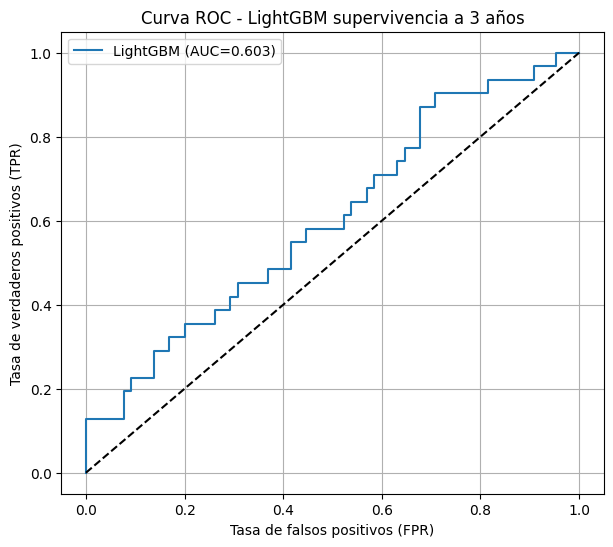

In [67]:
# Entrenamiento
lgbm_clf = LGBMClassifier(random_state=42, colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, num_leaves=31, subsample=0.8)
lgbm_clf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento
y_pred_train = lgbm_clf.predict_proba(X_train)[:,1]
auc_train = roc_auc_score(y_train, y_pred_train)
print(f"AUC ROC entrenamiento: {auc_train:.4f}")

# Métricas en test (original)
y_pred_test = lgbm_clf.predict_proba(X_test)[:,1]
auc_test = roc_auc_score(y_test, y_pred_test)
print(f"AUC ROC test: {auc_test:.4f}")

# Curva ROC para test
fpr, tpr, _ = roc_curve(y_test, y_pred_test)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC={auc_test:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - LightGBM supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC entrenamiento (SMOTE): 1.0000
AUC ROC test: 0.6119


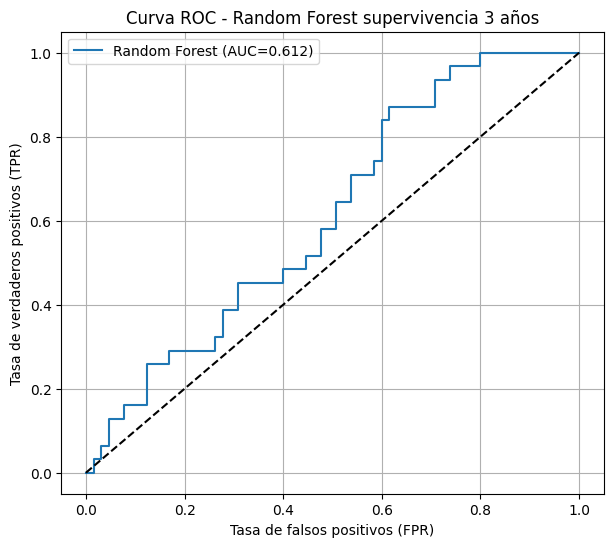

In [68]:
# Entrenamiento Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=1, max_features=0.3, max_depth=None, bootstrap=False)
rf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento balanceado
y_pred_train_rf = rf.predict_proba(X_train)[:,1]
auc_train_rf = roc_auc_score(y_train, y_pred_train_rf)
print(f"AUC ROC entrenamiento (SMOTE): {auc_train_rf:.4f}")

# Métricas en test original
y_pred_test_rf = rf.predict_proba(X_test)[:,1]
auc_test_rf = roc_auc_score(y_test, y_pred_test_rf)
print(f"AUC ROC test: {auc_test_rf:.4f}")

# Curva ROC para test
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_test_rf)
plt.figure(figsize=(7,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_test_rf:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest supervivencia 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC entrenamiento: 1.0000
AUC ROC test: 0.6447


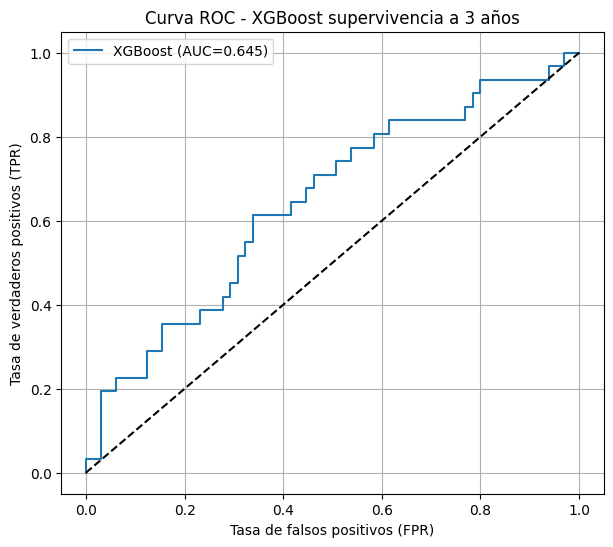

In [69]:
# Entrenamiento XGBoost
xgb_clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    colsample_bytree=0.6,
    gamma=0,
    random_state=42
)
xgb_clf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento balanceado
y_pred_train_xgb = xgb_clf.predict_proba(X_train)[:,1]
auc_train_xgb = roc_auc_score(y_train, y_pred_train_xgb)
print(f"AUC ROC entrenamiento: {auc_train_xgb:.4f}")

# Métricas en test original
y_pred_test_xgb = xgb_clf.predict_proba(X_test)[:,1]
auc_test_xgb = roc_auc_score(y_test, y_pred_test_xgb)
print(f"AUC ROC test: {auc_test_xgb:.4f}")

# Curva ROC en test
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_test_xgb)
plt.figure(figsize=(7,6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_test_xgb:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - XGBoost supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC entrenamiento (SMOTE): 1.0000
AUC ROC test: 0.6342


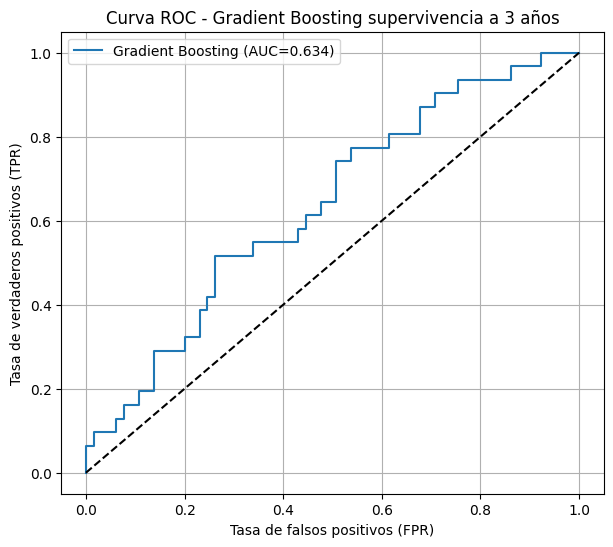

In [70]:
# Entrenamiento Gradient Boosting
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    random_state=42,
    max_features= 'sqrt',
    min_samples_leaf=2,
    min_samples_split=5
)
gb_clf.fit(X_train_smote, y_train_smote)

# Métricas en entrenamiento balanceado
y_pred_train_gb = gb_clf.predict_proba(X_train)[:,1]
auc_train_gb = roc_auc_score(y_train, y_pred_train_gb)
print(f"AUC ROC entrenamiento (SMOTE): {auc_train_gb:.4f}")

# Métricas en test original
y_pred_test_gb = gb_clf.predict_proba(X_test)[:,1]
auc_test_gb = roc_auc_score(y_test, y_pred_test_gb)
print(f"AUC ROC test: {auc_test_gb:.4f}")

# Curva ROC en test
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_test_gb)
plt.figure(figsize=(7,6))
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc_test_gb:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Gradient Boosting supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()


[LightGBM] [Info] Number of positive: 257, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003259 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40393
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 319
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

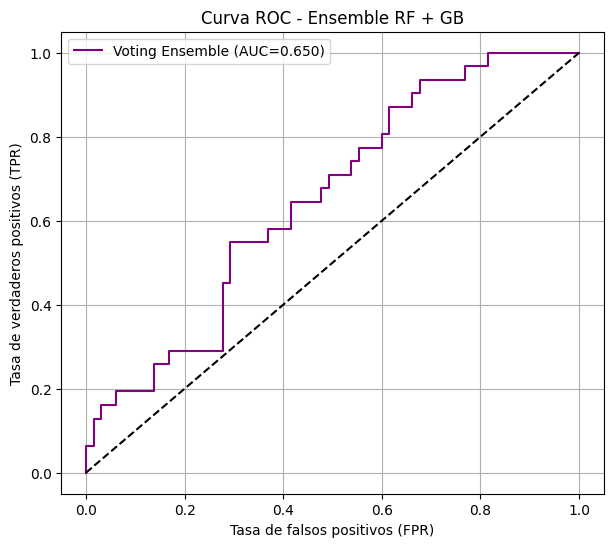

In [ ]:
from sklearn.ensemble import VotingClassifier

# Instanciar con tus modelos ya entrenados (o inicializados con los mismos parámetros)
ensemble_voting = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb_clf),
        ('xgb', xgb_clf),
        ('svm', best_model),
        ('lgbm', lgbm_clf)
    ],
    voting='soft'        # soft usa las probabilidades, hard usa clases
)

ensemble_voting.fit(X_train_smote, y_train_smote)

# Métricas en test
y_pred_test_ens = ensemble_voting.predict_proba(X_test)[:,1]
auc_test_ens = roc_auc_score(y_test, y_pred_test_ens)
print(f"AUC ROC Voting Ensemble (test): {auc_test_ens:.4f}")

fpr_ens, tpr_ens, _ = roc_curve(y_test, y_pred_test_ens)
plt.figure(figsize=(7,6))
plt.plot(fpr_ens, tpr_ens, label=f'Voting Ensemble (AUC={auc_test_ens:.3f})', color='purple')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Ensemble RF + GB')
plt.legend()
plt.grid(True)
plt.show()


[LightGBM] [Info] Number of positive: 257, number of negative: 257
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003776 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 40393
[LightGBM] [Info] Number of data points in the train set: 514, number of used features: 319
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits w

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


AUC ROC Stacking Ensemble (test): 0.6670


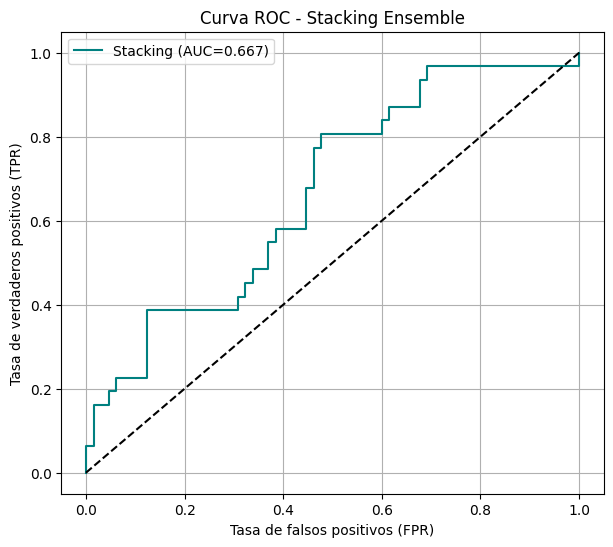

In [78]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# Stack tus modelos base y un meta-modelo (lo habitual: regresión logística)
stack_clf = StackingClassifier(
    estimators=[
        ('rf', rf),
        ('gb', gb_clf),
        ('xgb', xgb_clf),
        ('svm', best_model),
        ('lgbm', lgbm_clf)
    ],
    final_estimator=LogisticRegression(random_state=42),
    cv=5,          # validación interna de meta-modelo, puedes ajustar
    passthrough=True   # incluye X original en meta-modelo
)

stack_clf.fit(X_train_smote, y_train_smote)

# Métricas en test stacking
y_pred_test_stack = stack_clf.predict_proba(X_test)[:,1]
auc_test_stack = roc_auc_score(y_test, y_pred_test_stack)
print(f"AUC ROC Stacking Ensemble (test): {auc_test_stack:.4f}")

fpr_stack, tpr_stack, _ = roc_curve(y_test, y_pred_test_stack)
plt.figure(figsize=(7,6))
plt.plot(fpr_stack, tpr_stack, label=f'Stacking (AUC={auc_test_stack:.3f})', color='teal')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Stacking Ensemble')
plt.legend()
plt.grid(True)
plt.show()


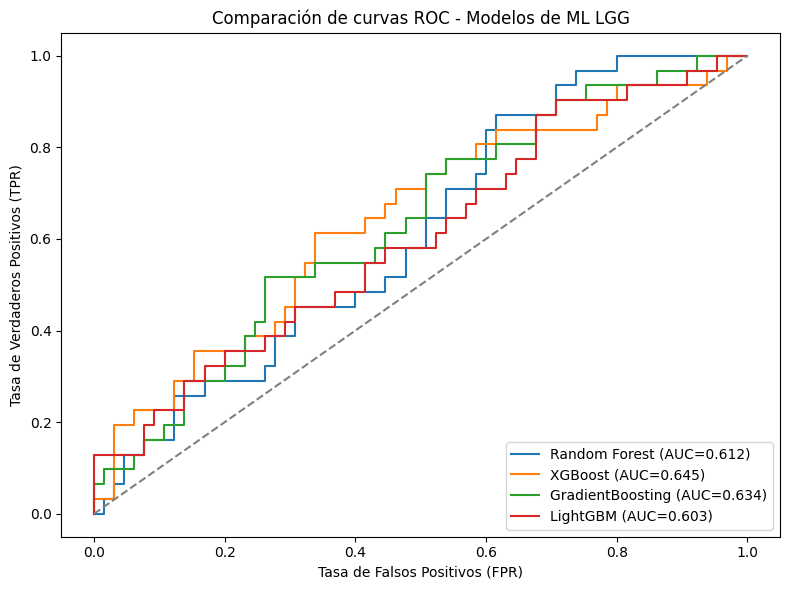

In [73]:
# Curvas ROC
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_test_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_test_xgb)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_pred_test_gb)
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_pred_test)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)
auc_gb = auc(fpr_gb, tpr_gb)
auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})')
plt.plot(fpr_gb, tpr_gb, label=f'GradientBoosting (AUC={auc_gb:.3f})')
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC={auc_lgbm:.3f})')
plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Comparación de curvas ROC - Modelos de ML LGG')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()
